## Myeloid subclusting and signatures

In [13]:
# Import packages
import scanpy as sc
import numpy as np
import pandas as pd
import os
import igraph

os.chdir("/Users/annacarolinafagundes/ibd-myeloid-scoring/")


In [2]:
#figure settings
sc.settings.figdir = "figures/scrna/Myeloid_reclustered/"

In [47]:
#load object
adata_myeloid = sc.read_h5ad("data/processed/scrna/adata_myeloid.h5ad")

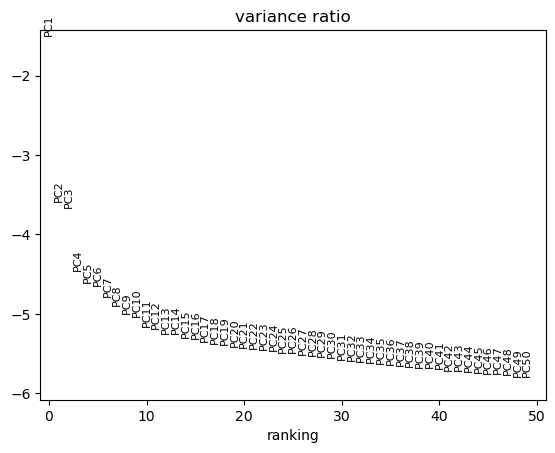

In [48]:
#Run PCA on myeloid subset
sc.tl.pca(adata_myeloid)

#Elbow plot
sc.pl.pca_variance_ratio(adata_myeloid, n_pcs=50, log=True, save="_myeloid_elbow.png")

In [49]:
#recompute neighbors on the subset
sc.pp.neighbors(adata_myeloid, n_pcs=12) #input value from Elbow plot

In [50]:
#order conditions
adata_myeloid.obs["condition"] = pd.Categorical(
    adata_myeloid.obs["condition"],
    categories=["HC", "CD", "UC"],
    ordered=True
)

In [51]:
#recompute UMAP for the subset
sc.tl.umap(adata_myeloid)

In [52]:
#try different resolutions
sc.tl.leiden(adata_myeloid, flavor="igraph", n_iterations=2, resolution=0.9, key_added="leiden_myeloid_0.9")
sc.tl.leiden(adata_myeloid, flavor="igraph", n_iterations=2, resolution=1.0, key_added="leiden_myeloid_1.0")
sc.tl.leiden(adata_myeloid, flavor="igraph", n_iterations=2, resolution=1.2, key_added="leiden_myeloid_1.2")
sc.tl.leiden(adata_myeloid, flavor="igraph", n_iterations=2, resolution=1.5, key_added="leiden_myeloid_1.5")
sc.tl.leiden(adata_myeloid, flavor="igraph", n_iterations=2, resolution=2.0, key_added="leiden_myeloid_2.0")

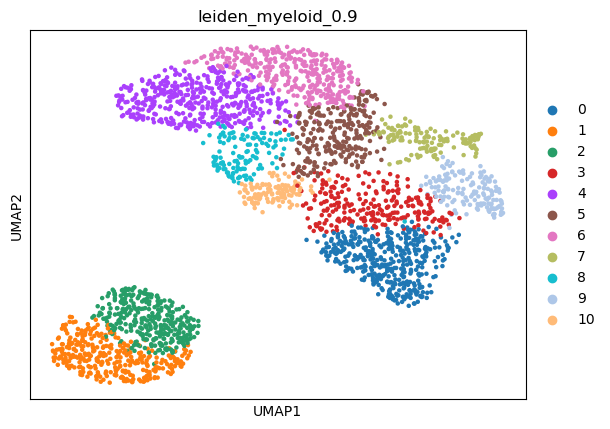

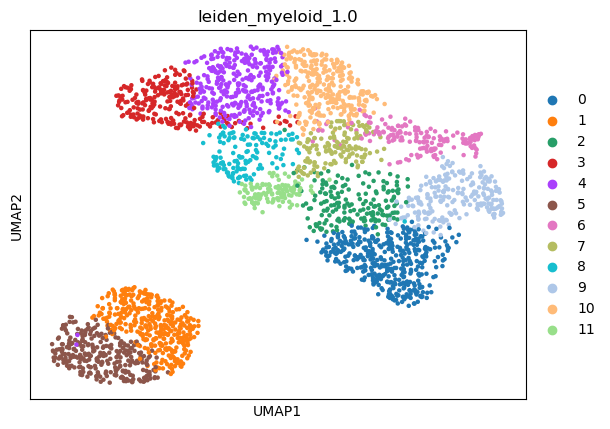

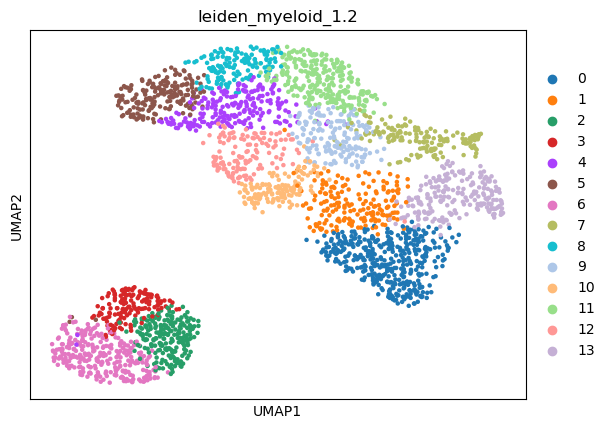

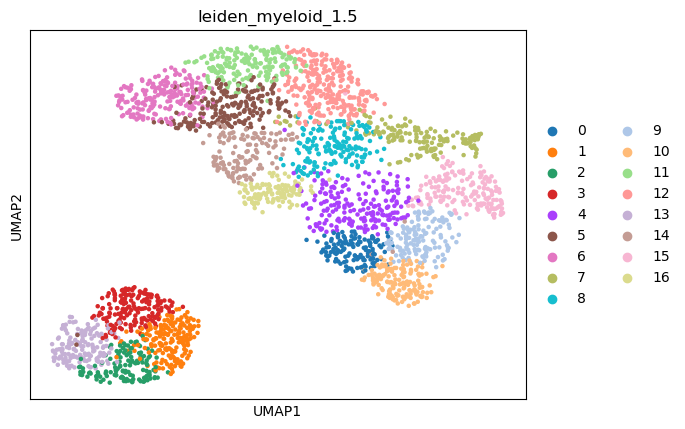

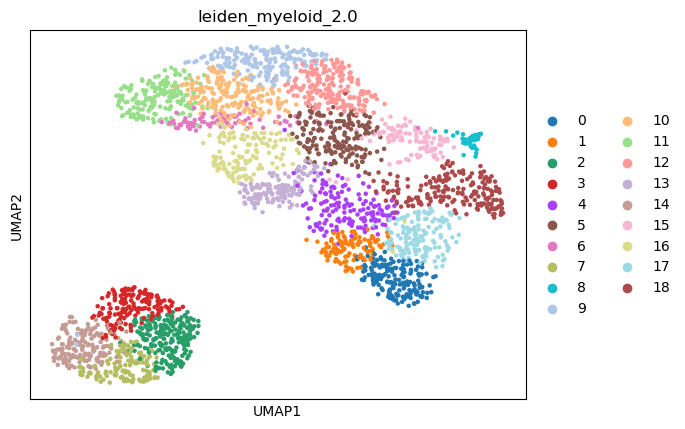

In [53]:
#plot and save umap
sc.pl.umap(adata_myeloid, color=["leiden_myeloid_0.9"],save="_myeloid_reclustered_0.9.png")
sc.pl.umap(adata_myeloid, color=["leiden_myeloid_1.0"],save="_myeloid_reclustered_1.0.png")
sc.pl.umap(adata_myeloid, color=["leiden_myeloid_1.2"],save="_myeloid_reclustered_1.2.png")
sc.pl.umap(adata_myeloid, color=["leiden_myeloid_1.5"],save="_myeloid_reclustered_1.5.png")
sc.pl.umap(adata_myeloid, color=["leiden_myeloid_2.0"],save="_myeloid_reclustered_2.0.png")

In [54]:
#reorder clusters
from pandas.api.types import CategoricalDtype

cluster_mapping = {
    "6": "0",
    "2": "1",
    "3": "2",
    "11": "3",
    "8": "4",
    "5": "5",
    "4": "6",
    "12": "7",
    "10": "8",
    "1": "9",
    "0":"10",
    "13":"11",
    "7":"12",
    "9":"13"
}
adata_myeloid.obs["leiden_myeloid_1.2"] = adata_myeloid.obs["leiden_myeloid_1.2"].map(cluster_mapping)
cat_type = CategoricalDtype(categories=["0","1","2","3","4","5","6","7","8","9","10","11","12","13"], ordered=True)
adata_myeloid.obs["leiden_myeloid_1.2"] = adata_myeloid.obs["leiden_myeloid_1.2"].astype(cat_type)

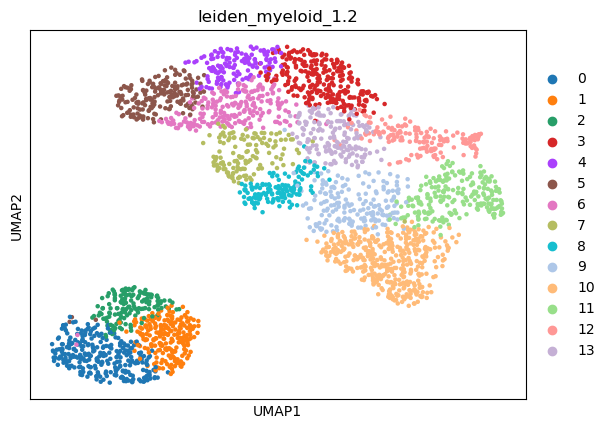

In [55]:
#plot and save umap
sc.pl.umap(adata_myeloid, color=["leiden_myeloid_1.2"],save="_myeloid_reclustered_1.2.png")

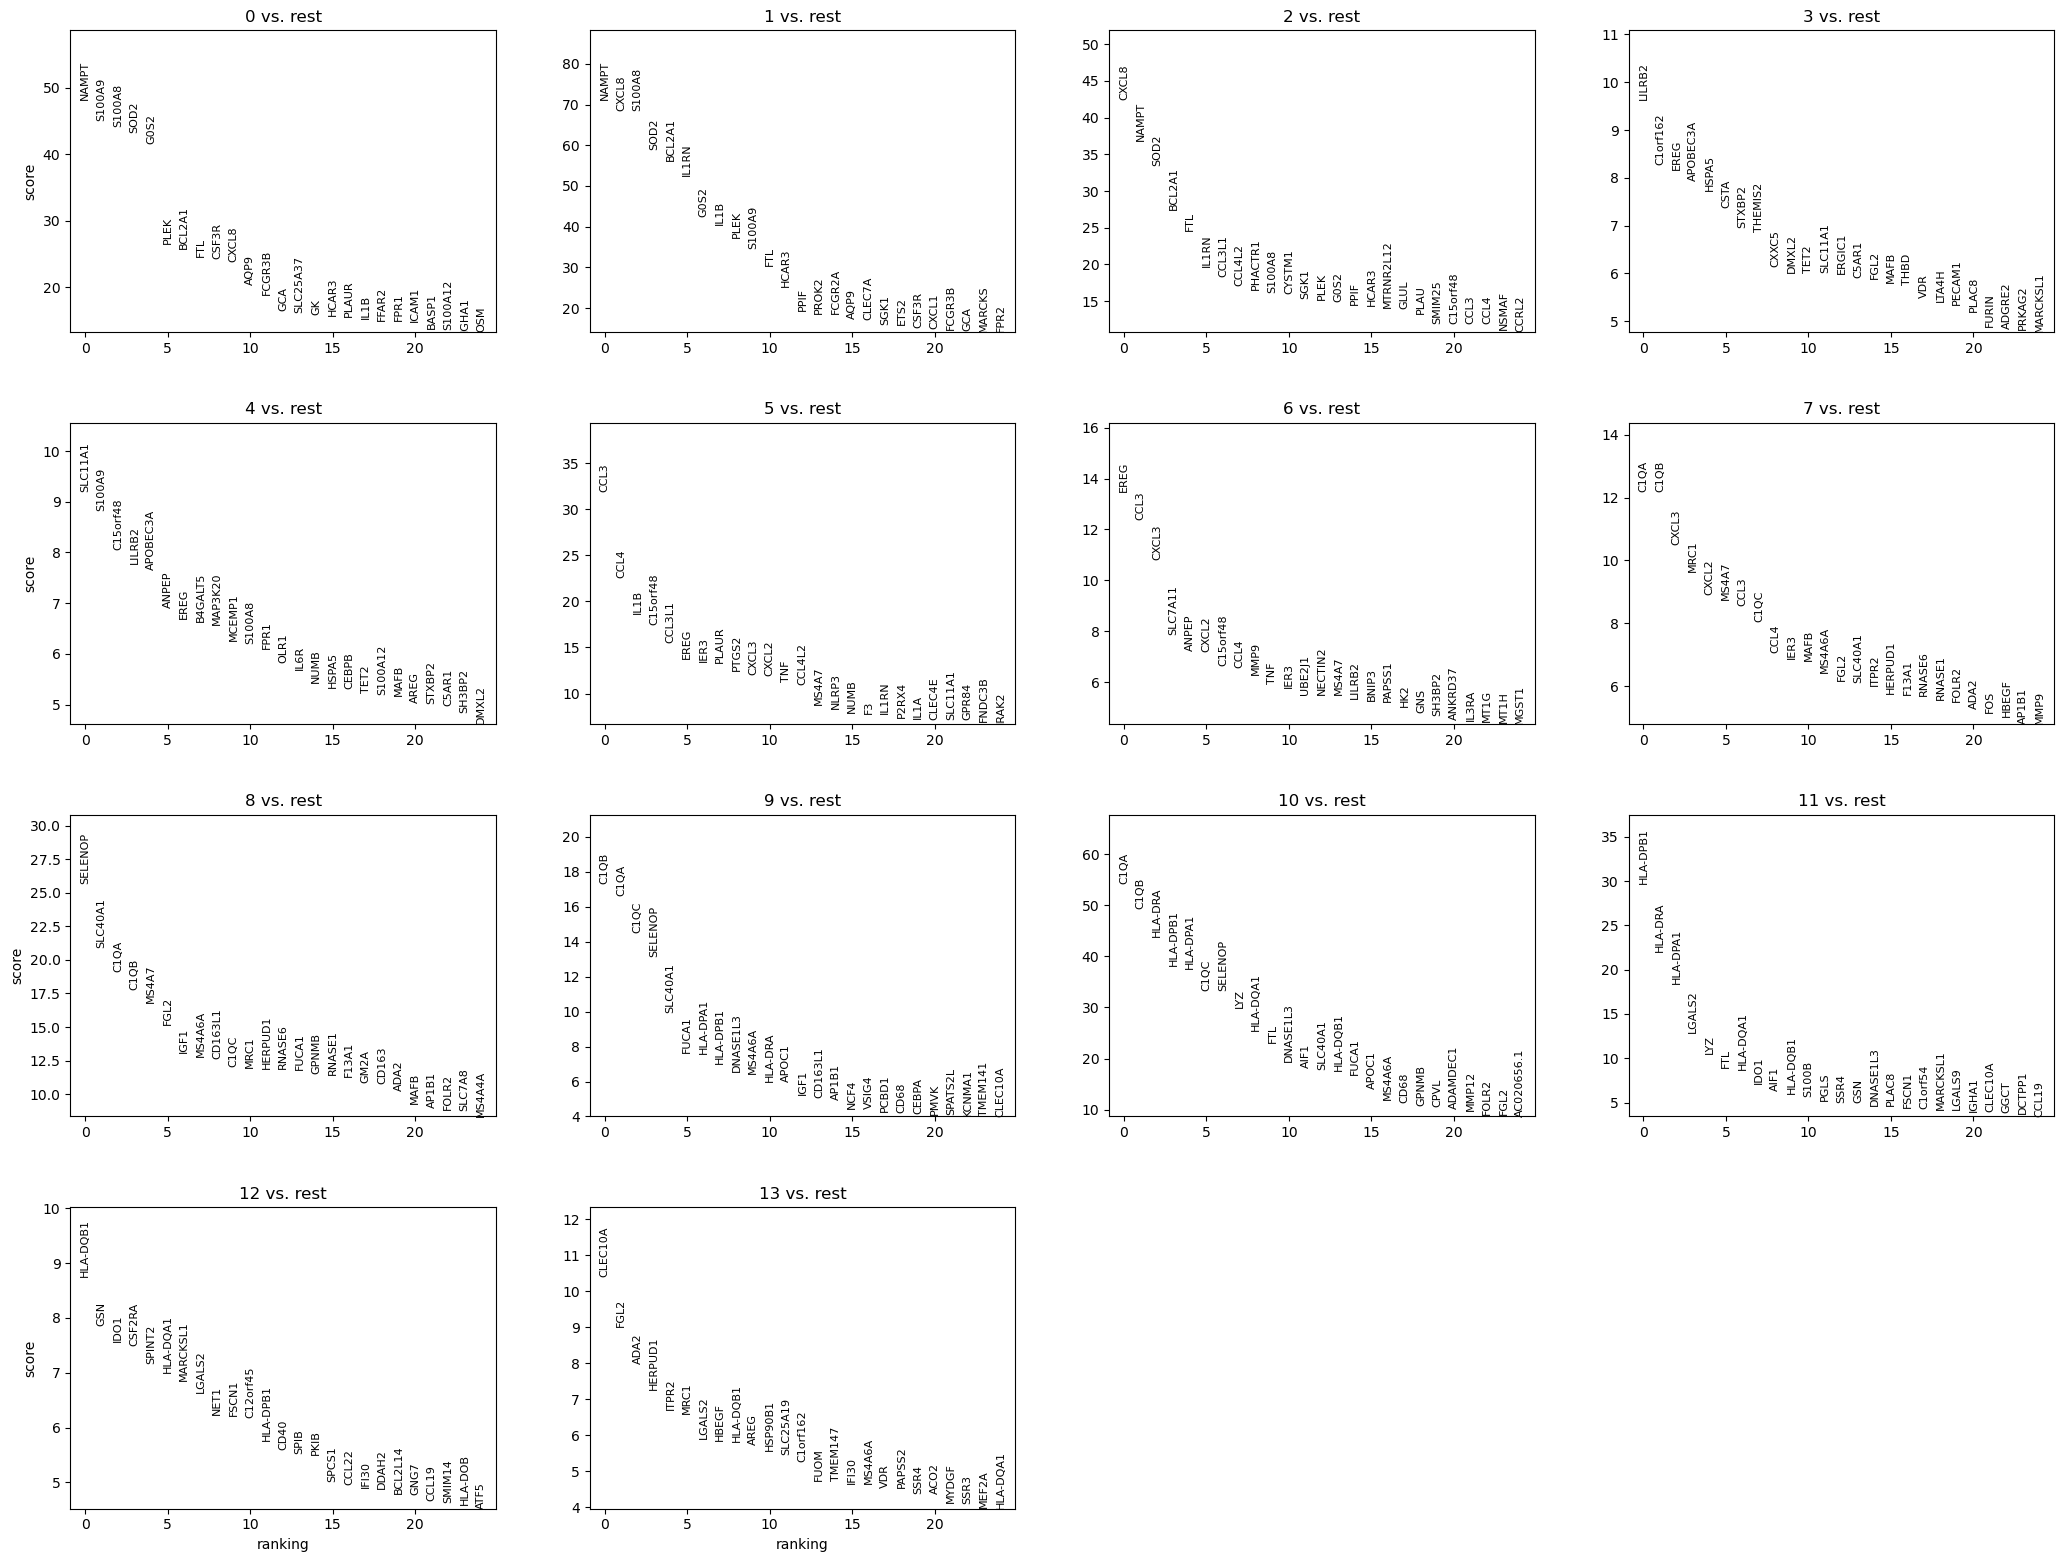

In [56]:
#Find marker genes
sc.tl.rank_genes_groups(adata_myeloid, "leiden_myeloid_1.2", mask_var="highly_variable", method="t-test")
sc.pl.rank_genes_groups(adata_myeloid, n_genes=25, sharey=False,save="_top25_res1.2.png")

In [57]:
#export results to excel
result = sc.get.rank_genes_groups_df(adata_myeloid, group=None)
result.to_excel("data/processed/scrna/myeloid_markers_res1.2.xlsx", index=False)

In [58]:
#export top 25 table and list
top25 = result.groupby("group").head(25)
top25.to_excel("data/processed/scrna/top25_myeloid_markers_res1.2.xlsx", index=False)
top25_genes = result.groupby("group")["names"].apply(lambda x: ",".join(x.head(25)))
top25_genes.to_csv("data/processed/scrna/top25_genes_per_cluster_res1.2.csv")

/var/folders/5x/6cxhjcxs5p79bg6pfvths8tr0000gn/T/ipykernel_23254/3368081914.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top25 = result.groupby("group").head(25)
/var/folders/5x/6cxhjcxs5p79bg6pfvths8tr0000gn/T/ipykernel_23254/3368081914.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top25_genes = result.groupby("group")["names"].apply(lambda x: ",".join(x.head(25)))


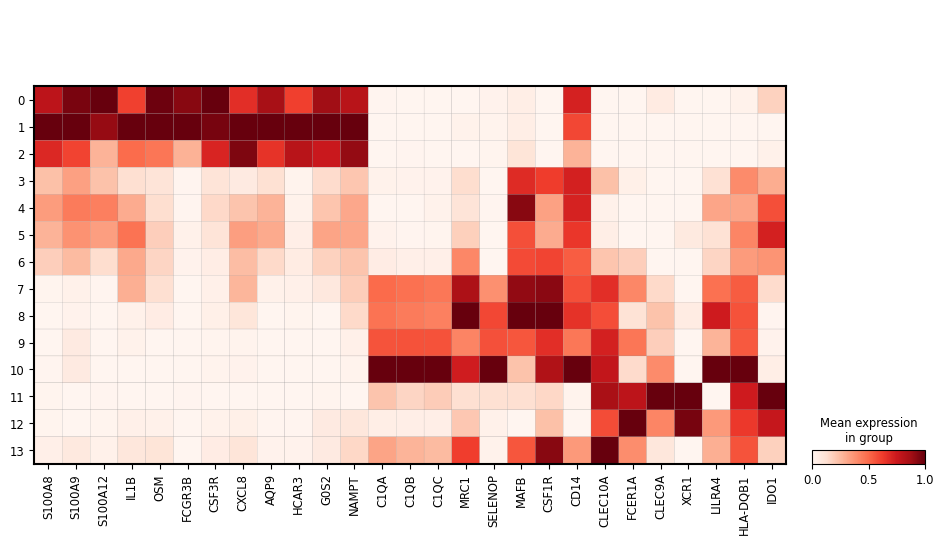

In [113]:
#plot main lineage markers
marker_lineages_myeloid = ["S100A8", "S100A9", "S100A12", "IL1B", "OSM",
                           "FCGR3B", "CSF3R", "CXCL8", "AQP9", "HCAR3", "G0S2", "NAMPT",
                           "C1QA", "C1QB", "C1QC", "MRC1", "SELENOP", "MAFB", "CSF1R","CD14", 
                           "CLEC10A", "FCER1A", "CLEC9A", "XCR1", "LILRA4", "HLA-DQB1", "IDO1"]

sc.pl.matrixplot(adata_myeloid, 
                marker_lineages_myeloid, 
                cmap="Reds",
                groupby='leiden_myeloid_1.2',
                standard_scale="var",
                save="_matrixplot_lineages.png")

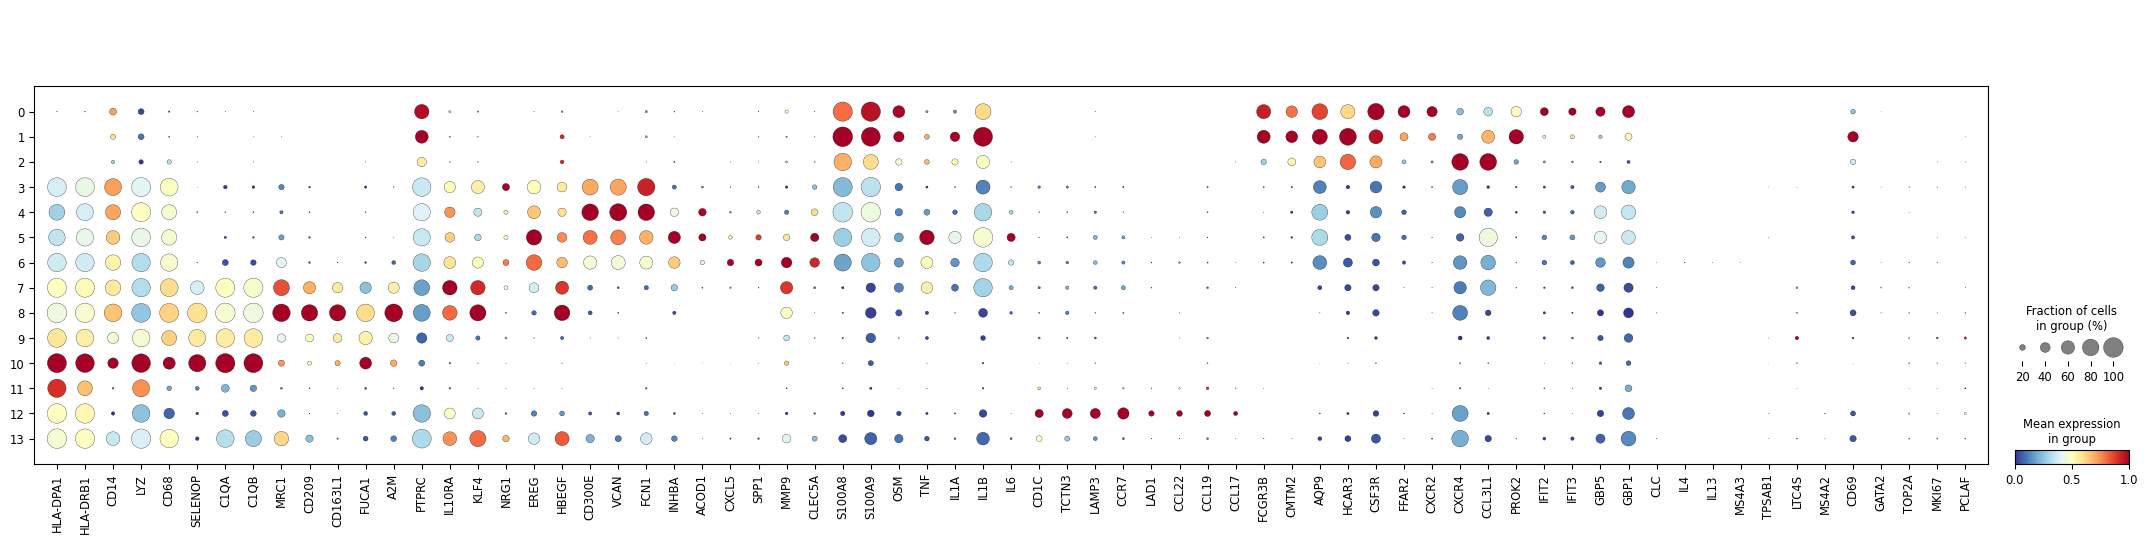

In [112]:
marker_paper = [
    # Macrophage/Monocyte
    "HLA-DPA1", "HLA-DRB1", "CD14", "LYZ", "CD68", "SELENOP", 
    "C1QA", "C1QB", "MRC1", "CD209", "CD163L1", "FUCA1",
    "A2M", "PTPRC", "IL10RA", "KLF4", "NRG1","EREG", 
    "HBEGF", "CD300E", "VCAN", "FCN1", "INHBA", "ACOD1", 
    "CXCL5", "SPP1", "MMP9", "CLEC5A", "S100A8", "S100A9",
    "OSM", "TNF", "IL1A", "IL1B",
    # DC
    "IL6", "CD1C", "TCTN3", "LAMP3", "CCR7", "LAD1", "CCL22",
    "CCL19", "CCL17", "FCGR3B", "CMTM2", "AQP9", "HCAR3",
    "CSF3R", "FFAR2", "CXCR2", "CXCR4", "CCL3L1",
    # Neutrophil/Mast
   "PROK2", "IFIT2", "IFIT3", "GBP5", "GBP1", "CLC",
    "IL4", "IL13", "MS4A3", "TPSAB1", "LTC4S", "MS4A2",
    "CD69", "GATA2", "TOP2A", "MKI67", "PCLAF"
]

sc.pl.dotplot(
    adata_myeloid,
    marker_paper,
    groupby="leiden_myeloid_1.2",
    cmap="RdYlBu_r",
    standard_scale="var",
    show=True,
    save="paper_markers_1.2.png")

In [104]:
#Add annotation to object
annotation = {
    "0": "Neutrophil 3",
    "1": "Neutrophil 1",
    "2": "Neutrophil 2",
    "3": "Inflammatory Monocytes",
    "4": "M1 Macrophages",
    "5": "M1 Macrophages",
    "6": "Mixed Macrophages",
    "7": "M2 Macrophages",
    "8": "M2 Macrophages",
    "9": "M2.2 Macrophages",
    "10":"M0 Macrophages",
    "11": "M0_Ribhi Macrophages",
    "12": "DCs",
    "13": "IDA Macrophages"
}

adata_myeloid.obs["cell_type"]=adata_myeloid.obs["leiden_myeloid_1.2"].map(annotation)



In [105]:
#order
from pandas.api.types import CategoricalDtype
cell_type_order = [
    "Neutrophil 3",
    "Neutrophil 1",
    "Neutrophil 2",
    "Inflammatory Monocytes",
    "M1 Macrophages",
    "Mixed Macrophages",
    "M2 Macrophages",
    "M2.2 Macrophages",
    "M0 Macrophages",
    "M0_Ribhi Macrophages",
    "DCs",
    "IDA Macrophages"
]

cat_type = CategoricalDtype(categories=cell_type_order, ordered=True)
adata_myeloid.obs["cell_type"] = adata_myeloid.obs["cell_type"].astype(cat_type)

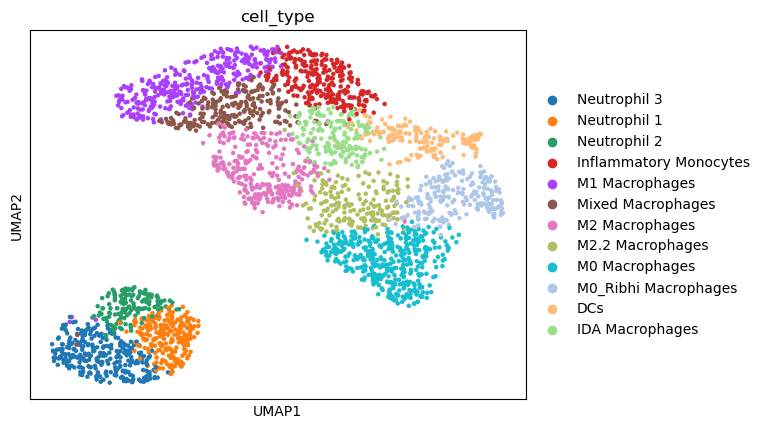

In [106]:
#plot umap and save object
sc.pl.umap(adata_myeloid, color=["cell_type"],save="_annotated.png")

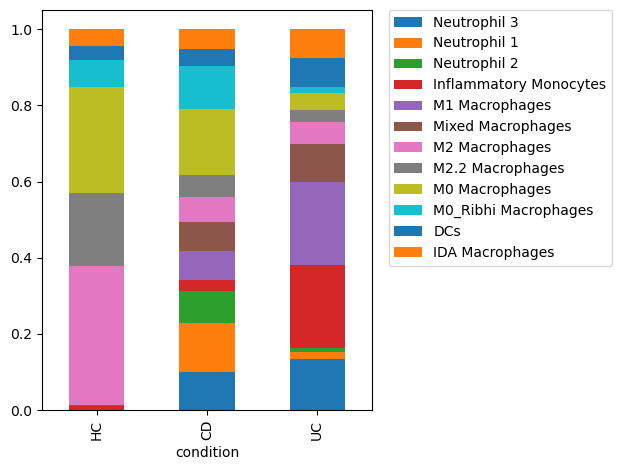

In [121]:
#calculate cluster frequencies
import matplotlib.pyplot as plt

tmp = pd.crosstab(adata_myeloid.obs['cell_type'],
    adata_myeloid.obs['condition'], 
    normalize='columns').T.plot(kind='bar', stacked=True)

tmp.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.)
plt.savefig("figures/scrna/Myeloid_reclustered/barplot_cluster_proportions.png", bbox_inches="tight", dpi=150)
plt.tight_layout()

## Calculate similarity index between annotation and paper

In [108]:
# add paper annotation to myeloid object
metadata = pd.read_csv("data/raw/scrna/GSE214695_cell_annotation.csv")

sample_mapping = {
    "HC1": "GSM6614348_HC-1", "HC2": "GSM6614349_HC-2",
    "HC3": "GSM6614350_HC-3", "HC4": "GSM6614351_HC-4",
    "HC5": "GSM6614352_HC-5", "HC6": "GSM6614353_HC-6",
    "UC1": "GSM6614354_UC-1", "UC2": "GSM6614355_UC-2",
    "UC3": "GSM6614356_UC-3", "UC4": "GSM6614357_UC-4",
    "UC5": "GSM6614358_UC-5", "UC6": "GSM6614359_UC-6",
    "CD1": "GSM6614360_CD-1", "CD2": "GSM6614361_CD-2",
    "CD3": "GSM6614362_CD-3", "CD4": "GSM6614363_CD-4",
    "CD5": "GSM6614364_CD-5", "CD6": "GSM6614365_CD-6",
}

metadata["sample_gsm"] = metadata["sample"].map(sample_mapping)
metadata["unique_id"] = metadata["sample_gsm"] + "_" + metadata["cell_id"]
metadata_deduped = metadata.drop_duplicates(subset="unique_id").set_index("unique_id")

adata_myeloid.obs["unique_id"] = adata_myeloid.obs["sample"].astype(str) + "_" + adata_myeloid.obs_names
adata_myeloid.obs["paper_annotation"] = adata_myeloid.obs["unique_id"].map(metadata_deduped["annotation"])

print(f"Overlap: {adata_myeloid.obs['paper_annotation'].notna().sum()} / {adata_myeloid.n_obs} cells annotated")
print(adata_myeloid.obs["paper_annotation"].value_counts())

Overlap: 2641 / 2863 cells annotated
paper_annotation
Neutrophil 1              361
IDA macrophage            343
M0                        295
M0_Ribhi                  277
M1 ACOD1                  270
Inflammatory monocytes    222
M2                        163
Neutrophil 2              148
M2.2                      143
Neutrophil 3              141
M1 CXCL5                   99
DCs CD1c                   84
DCs CCL22                  28
Cycling myeloid            25
DCs CCL22_Ribhi            24
Cycling cells               7
B cell Ribhi                4
Eosinophils                 4
Mast 1                      1
Lymphatic endothelium       1
B cell                      1
Name: count, dtype: int64


In [110]:
# crosstab between annotation and paper's
confusion = pd.crosstab(
    adata_myeloid.obs["cell_type"],
    adata_myeloid.obs["paper_annotation"],
    normalize="index"  # normalize by row (clusters)
)

print(confusion)

paper_annotation          B cell  B cell Ribhi  Cycling cells  \
cell_type                                                       
Neutrophil 3            0.000000      0.000000       0.000000   
Neutrophil 1            0.000000      0.000000       0.000000   
Neutrophil 2            0.000000      0.000000       0.000000   
Inflammatory Monocytes  0.004219      0.000000       0.004219   
M1 Macrophages          0.000000      0.000000       0.000000   
Mixed Macrophages       0.000000      0.000000       0.000000   
M2 Macrophages          0.000000      0.000000       0.000000   
M2.2 Macrophages        0.000000      0.000000       0.000000   
M0 Macrophages          0.000000      0.000000       0.000000   
M0_Ribhi Macrophages    0.000000      0.019512       0.019512   
DCs                     0.000000      0.000000       0.017391   
IDA Macrophages         0.000000      0.000000       0.000000   

paper_annotation        Cycling myeloid  DCs CCL22  DCs CCL22_Ribhi  DCs CD1c  \
cell_typ

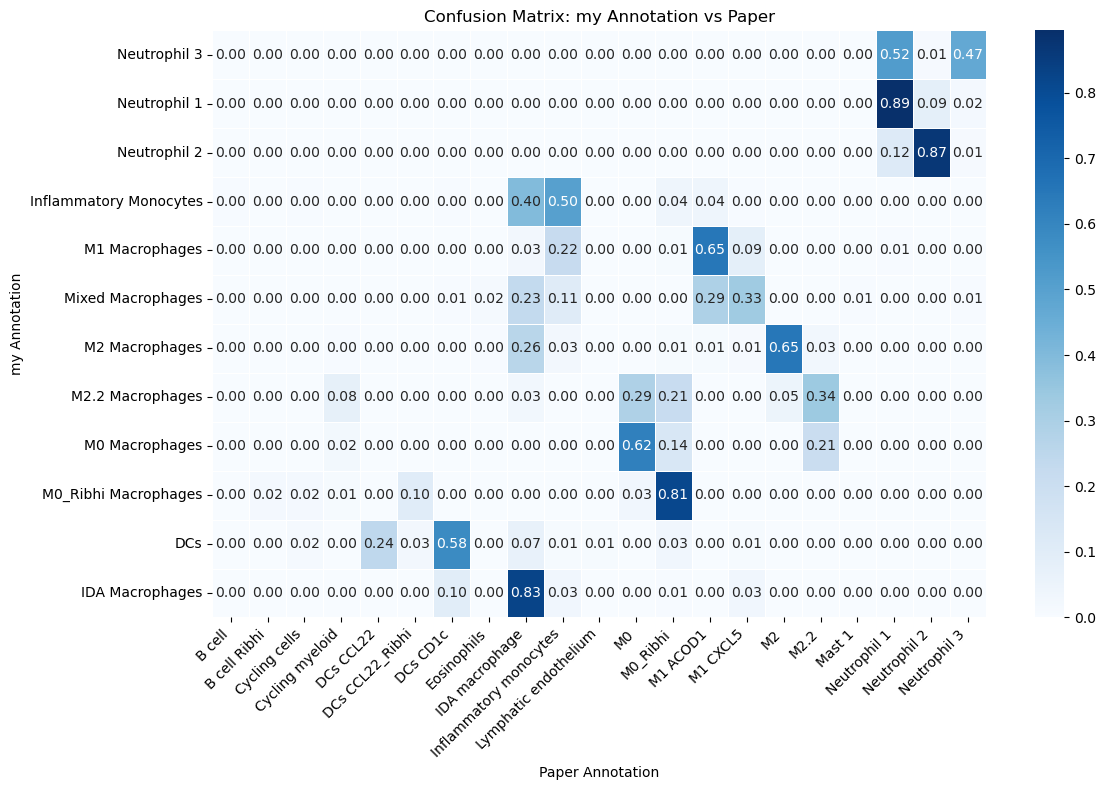

In [120]:
#plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(
    confusion,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)
plt.title("Confusion Matrix: my Annotation vs Paper")
plt.xlabel("Paper Annotation")
plt.ylabel("my Annotation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/scrna/Myeloid_reclustered/confusionmatrix_1.2.png",bbox_inches="tight")
plt.show()


In [114]:
#save annotated object
adata_myeloid.write("data/processed/scrna/adata_myeloid_annotated.h5ad")
